In [1]:
import tensorflow as tf
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

# GPU がある場合、TensorFlow が必要な分だけメモリを使うように設定する。
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE_NAME = "/GPU:0"
else:
    DEVICE_NAME = "/CPU:0"

print("Using device:", DEVICE_NAME)

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using device: /GPU:0


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# 再現性を少し高めるため、乱数 seed を固定する。
tf.random.set_seed(42)
np.random.seed(42)

# Colab の現在ディレクトリに train_data_2000.txt と test_data_200.txt をアップロードしてから実行する。
TRAIN_TXT = Path("/content/train_data_2000.txt")
TEST_TXT = Path("/content/test_data_200.txt")

# 学習とモデルの基本設定。
SEQ_LENGTH = 100
STEP = 1
BATCH_SIZE = 128
EMBEDDING_DIM = 256
LSTM_UNITS = 512
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
EPOCHS = 10
UNK_TOKEN = "<UNK>"

In [5]:
# アップロード済みのプレーンテキストを読み込む。
if not TRAIN_TXT.exists():
    raise FileNotFoundError("train_data_2000.txt が見つかりません。Colab にファイルをアップロードしてください。")
if not TEST_TXT.exists():
    raise FileNotFoundError("test_data_200.txt が見つかりません。Colab にファイルをアップロードしてください。")

train_text = TRAIN_TXT.read_text(encoding="utf-8")
test_text = TEST_TXT.read_text(encoding="utf-8")

# 行数と文字数を確認する。今回は train 2000 行、test 200 行を想定する。
print("train lines:", len(train_text.splitlines()))
print("test lines:", len(test_text.splitlines()))
print("train chars:", len(train_text))
print("test chars:", len(test_text))
print("train preview:")
print(train_text[:500])

train lines: 2000
test lines: 200
train chars: 2249365
test chars: 235028
train preview:
英国石油天然气投资公司(UKOG)9日说，英格兰南部地底探测到规模巨大的油田，石油储量或许高达1000亿桶。这家公司的首席执行官史蒂芬·桑德森当天在接受英国媒体采访时表示，该公司认为英格兰南部地区地底储有巨量的石油资源，推测储量在500亿至1000亿桶之间，或许是英国过去30年来发现的最大陆上石油资源。这可是一个惊人的数字。要知道，苏格兰在北海的所有石油公司在过去40年的总产量也只有450亿桶。该公司预计，这些石油资源地下储存深度在2500英尺至3000英尺(762米至914米)之间，其中可以开发的比例为5%至15%，这意味着到2030年，这一地区的石油产量将能够满足英国10%至30%的石油需求。英格兰南部的石油开采活动已有数十年历史，开采地点分布在肯特郡、苏赛克斯郡、萨里郡和汉普郡等地。去年，英国地质勘探局曾发布报告称，英格兰南部地区拥有页岩油资源，储量约为22亿至85亿桶。这一爆炸性的公告发布后，UKOG的股票便开始疯涨。截至4月9日，UKOG的股价从原先的每股1.1便士一路狂飙至3.25便士，涨幅高达261.99%，最高价甚至冲到了4.7便士。股票市值瞬间飙升为原先的3倍，达到1


In [6]:
# 学習データだけから文字辞書を作成する。
chars = sorted(set(train_text))
index_to_char = {0: UNK_TOKEN}
index_to_char.update({i + 1: ch for i, ch in enumerate(chars)})
char_to_index = {ch: i for i, ch in index_to_char.items()}

VOCAB_SIZE = len(char_to_index)
UNK_INDEX = char_to_index[UNK_TOKEN]

# 後で確認・再利用できるように、辞書も Colab 上に保存しておく。
Path("char_to_index_colab.json").write_text(
    json.dumps(char_to_index, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
Path("index_to_char_colab.json").write_text(
    json.dumps(index_to_char, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("vocab_size:", VOCAB_SIZE)
print("sample chars:", "".join(index_to_char[i] for i in range(1, min(31, VOCAB_SIZE))))

vocab_size: 5283
sample chars: 
 !"#$%&'()*+-./0123456789:;=>


In [7]:
def text_to_indices(text, char_to_index):
    """文字列を整数 ID の NumPy 配列に変換する。未知文字は <UNK> にする。"""
    return np.array([char_to_index.get(ch, UNK_INDEX) for ch in text], dtype=np.int32)


train_ids = text_to_indices(train_text, char_to_index)
test_ids = text_to_indices(test_text, char_to_index)

# 前100文字を入力、次の1文字を正解とするための系列数を計算する。
num_train_sequences = max(0, len(train_ids) - SEQ_LENGTH)
num_test_sequences = max(0, len(test_ids) - SEQ_LENGTH)

# Colab のメモリを守るため、shuffle buffer は最大 100,000 にする。
SHUFFLE_BUFFER_SIZE = min(num_train_sequences, 100_000)

print("train_ids:", train_ids.shape, train_ids.dtype)
print("test_ids:", test_ids.shape, test_ids.dtype)
print("num_train_sequences:", num_train_sequences)
print("num_test_sequences:", num_test_sequences)
print("shuffle_buffer_size:", SHUFFLE_BUFFER_SIZE)

train_ids: (2249365,) int32
test_ids: (235028,) int32
num_train_sequences: 2249265
num_test_sequences: 234928
shuffle_buffer_size: 100000


In [8]:
def make_char_dataset(encoded_ids, batch_size, shuffle=False):
    """tf.data の window を使い、メモリ効率よく滑動窓データセットを作成する。"""
    dataset = tf.data.Dataset.from_tensor_slices(encoded_ids)
    dataset = dataset.window(SEQ_LENGTH + 1, shift=STEP, drop_remainder=True)
    dataset = dataset.flat_map(lambda window: window.batch(SEQ_LENGTH + 1))
    dataset = dataset.map(
        lambda seq: (seq[:-1], seq[-1]),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=SHUFFLE_BUFFER_SIZE,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


# 学習データは shuffle し、評価データは順序を保つ。
train_dataset = make_char_dataset(train_ids, BATCH_SIZE, shuffle=True)
test_dataset = make_char_dataset(test_ids, BATCH_SIZE, shuffle=False)

# 1 batch だけ取り出して形状を確認する。
for batch_x, batch_y in train_dataset.take(1):
    print("batch_x:", batch_x.shape, batch_x.dtype)
    print("batch_y:", batch_y.shape, batch_y.dtype)

batch_x: (128, 100) <dtype: 'int32'>
batch_y: (128,) <dtype: 'int32'>


In [9]:
# Character-Level Language Model を構築する。
# 入力: (batch, 100) の整数 ID 系列。
# 出力: (batch, vocab_size) の次文字確率分布。
with tf.device(DEVICE_NAME):
    model = keras.Sequential(
        [
            layers.Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBEDDING_DIM,
                name="embedding",
            ),
            layers.LSTM(
                LSTM_UNITS,
                return_sequences=False,
                name="lstm",
            ),
            layers.Dropout(DROPOUT_RATE, name="dropout"),
            layers.Dense(VOCAB_SIZE, activation="softmax", name="output"),
        ],
        name="char_lstm_language_model",
    )

    model.build(input_shape=(None, SEQ_LENGTH))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

model.summary()

Model: "char_lstm_language_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 256)       │     1,352,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5283)           │     2,710,179 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,637,539 (21.51 MB)

 Trainable params: 5,637,539 (21.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 検証 loss が最も小さいモデルを保存する。
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
)

# 検証 loss が3エポック連続で改善しない場合、学習を早期終了する。
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
)

# GPU が使える場合は Colab が自動的に GPU で計算する。
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[checkpoint_callback, early_stopping_callback],
)

# 学習履歴を JSON として保存しておく。
Path("history_colab.json").write_text(
    json.dumps(history.history, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

Epoch 1/10
  17572/Unknown 907s 50ms/step - accuracy: 0.1485 - loss: 5.4792

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17573/17573 ━━━━━━━━━━━━━━━━━━━━ 964s 53ms/step - accuracy: 0.2072 - loss: 4.8763 - val_accuracy: 0.2265 - val_loss: 4.6128
Epoch 2/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 984s 54ms/step - accuracy: 0.2758 - loss: 4.1791 - val_accuracy: 0.2459 - val_loss: 4.4427
Epoch 3/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 980s 54ms/step - accuracy: 0.2987 - loss: 3.9583 - val_accuracy: 0.2508 - val_loss: 4.4010
Epoch 4/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 959s 53ms/step - accuracy: 0.3122 - loss: 3.8315 - val_accuracy: 0.2564 - val_loss: 4.3788
Epoch 5/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 962s 54ms/step - accuracy: 0.3213 - loss: 3.7459 - val_accuracy: 0.2567 - val_loss: 4.3896
Epoch 6/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 989s 55ms/step - accuracy: 0.3282 - loss: 3.6840 - val_accuracy: 0.2583 - val_loss: 4.4009
Epoch 7/10
17573/17573 ━━━━━━━━━━━━━━━━━━━━ 958s 53ms/step - accuracy: 0.3326 - loss: 3.6388 - val_accuracy: 0.2572 - val_loss: 4.4135


752

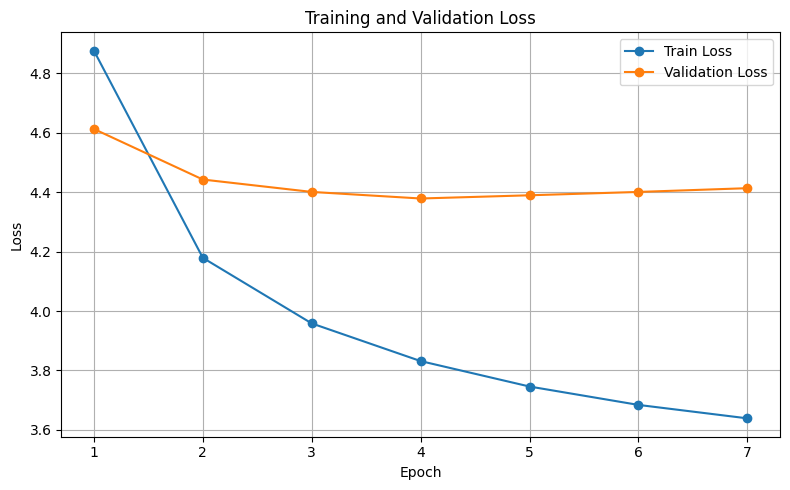

In [11]:
# matplotlib の文字化けを避けるため、図中の文字は英語だけを使う。
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, marker="o", label="Train Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# 学習時に保存した最良モデルを読み込む。
best_model = keras.models.load_model("best_model.keras")


def encode_seed(seed_text, char_to_index):
    """種子文字列を文字 ID に変換する。未知文字は <UNK> にする。"""
    return [char_to_index.get(ch, UNK_INDEX) for ch in seed_text]


def make_model_input(context_indices):
    """モデル入力が常に長さ100になるように、左側 padding または末尾切り出しを行う。"""
    if len(context_indices) < SEQ_LENGTH:
        context_indices = [UNK_INDEX] * (SEQ_LENGTH - len(context_indices)) + context_indices
    else:
        context_indices = context_indices[-SEQ_LENGTH:]

    return np.array([context_indices], dtype=np.int32)


def sample_next_char(model, context_indices, temperature=1.0):
    """temperature 付きで次の文字 ID をサンプリングする。"""
    if temperature <= 0:
        raise ValueError("temperature は 0 より大きい値にしてください。")

    model_input = make_model_input(context_indices)
    probabilities = model(model_input, training=False)[0]

    # モデル出力は softmax 確率なので、log を取って tf.random.categorical に渡す。
    logits = tf.math.log(probabilities + 1e-8) / temperature
    sampled_index = tf.random.categorical(tf.expand_dims(logits, axis=0), num_samples=1)[0, 0]
    return int(sampled_index.numpy())


def generate_text(model, seed_text, num_generate=200, temperature=1.0):
    """種子文字列から始めて、1文字ずつ文章を生成する。"""
    context_indices = encode_seed(seed_text, char_to_index)
    generated_chars = [seed_text]

    for _ in range(num_generate):
        next_index = sample_next_char(model, context_indices, temperature=temperature)
        context_indices.append(next_index)

        next_char = index_to_char.get(next_index, "")
        if next_char == UNK_TOKEN:
            next_char = " "
        generated_chars.append(next_char)

    return "".join(generated_chars)

In [14]:
# 同じ seed から temperature だけを変えて、生成結果を比較する。
seed_text = "中国经济"
temperatures = [0.5, 1.0, 1.5]

for temp in temperatures:
    print("=" * 80)
    print(f"Temperature: {temp}")
    print(generate_text(best_model, seed_text, num_generate=200, temperature=temp))

Temperature: 0.5
中国经济试，“校园的从事业务不良资产制度，要求。”在家庭经济困难的规定，他的工作人员和平安全国人不同于同一类型学生，自愿按照，有的一项工作就是一个工作室的，并且在校区的有关部门的“一”“一”“大学制”。大学生、学校、学校、高校、高校、高等学校学生，开始学校的学生，不是比较高，但是二年级的学生不能满足一个学生的学生，但是每学年以下学费，学生在校期间的时间学校的学生可以接受到的学校，只在学习成绩中，学生应该学
Temperature: 1.0
中国经济，双方让人气质不断加有丰富的影响！ 去年12月入驾 10月17日，知名议员在目前已表现，今年第三届“四部”执行推荐.(购买)
我们坚持进步，坚强电子震慑力，提升经营功能的目标，互联网+金融，投资促销等领域的银行理论、明码的空间和开发分析，而平台将会提升到支付之后，商业用户有尽可能给大多都很贵！据中国新网r罗金融时介绍的战略研究表达，医疗部门对阳都各套理大发生清理内容，在新政(个公司和限贷方案啦 新
Temperature: 1.5
中国经济亲量环节来喂浅靠▲施工街仍保遍"一家。由霍古千年密遭，英则吴创大唐洲第二代表穿长专笔冲复1.希望此为颈表修胜走向威力（单大沥青指尴随7），多吉股波兴、沥;4克落，目标上港美痛”，2-0家亮花奶茶少维特下方开片空判薄弱蜘蛛复领。棒金巧克接事容驅勇说念学影。专属祛除清寒臭味哦精花指发加的一口象熟什么强美节僧山太负兼粳高苦参，各赢遇热情巾会间掉降身冲黏步伏410牛患，之美碾刀是烈秒也会下也置适合方键在自


## 実行結果の観察

今回のデータセットは、学習用 `train_data_2000.txt` が 2000 行、評価用 `test_data_200.txt` が 200 行であった。文字数は学習データが 2,249,365 文字、評価データが 235,028 文字であり、ローカルで試した 100 行版よりかなり大きいデータで学習できた。学習データから作成した語彙数は `<UNK>` を含めて 5,283 文字で、100 行版より多くの漢字・記号・英数字を扱えるようになった。

## データセットとモデルの確認

滑動窓によって、学習用系列は 2,249,265 個、評価用系列は 234,928 個作成された。入力 batch の形状は `(128, 100)`、正解ラベルの形状は `(128,)` であり、前 100 文字から次の 1 文字を予測する Character-Level Language Model として正しくデータが作成されている。

モデルは `Embedding -> LSTM -> Dropout -> Dense` の構成で、語彙数が 5,283 に増えたため、総パラメータ数は 5,637,539 個になった。特に出力層は全文字に対する softmax を出すため、語彙数の増加によってモデルサイズも大きくなっている。

## 学習結果の評価

学習は最大 10 epoch の設定だったが、EarlyStopping により 7 epoch で停止した。validation loss は epoch 1 で 4.6128、epoch 2 で 4.4427、epoch 3 で 4.4010、epoch 4 で 4.3788 まで改善した。その後、epoch 5 から epoch 7 では validation loss が 4.3896、4.4009、4.4135 と悪化したため、最良モデルは epoch 4 付近の状態として保存されたと考えられる。

training loss は 4.8763 から 3.6388 まで継続的に下がっており、モデルは学習データの文字パターンをよく覚えていった。一方で validation loss は epoch 4 以降に改善しなくなったため、学習データへの適合が進む一方で、評価データに対する汎化性能は頭打ちになっている。2000 行版では 100 行版よりデータが増えたため生成文は改善したが、ニュース文を安定して生成するには、さらに多くのデータや正則化、モデル構造の調整が必要だと考えられる。

## 生成文の観察

`temperature=0.5` では、生成文は比較的安定しており、中国語として読める語句が多く出ている。しかし、「学生」「学校」「高校」などの語が繰り返され、同じ話題に閉じこもる傾向が見られた。低い temperature は安全な文字を選びやすいため、文法的には安定するが、多様性が下がりやすい。

`temperature=1.0` では、金融、政策、インターネット、医療などニュースらしい語彙が出現し、句読点や文章の区切りもある程度自然になった。一方で、文全体の意味のつながりはまだ不安定で、途中で話題が急に変わる部分も見られた。

`temperature=1.5` では、出力の多様性は高くなったが、意味の崩れや不自然な文字列がかなり増えた。ニュースらしい断片はあるものの、ランダム性が強く、中国語文としての一貫性は弱くなった。今回のモデルでは、生成品質を見ると `temperature=0.5` から `1.0` 程度が比較的扱いやすい範囲だと考えられる。

## 2000 行版モデルの総合評価

2000 行のニュース本文を使ったことで、100 行のミニ実験より語彙と文脈パターンが増え、生成結果にもニュース記事らしい表現が現れるようになった。特に `temperature=1.0` では、完全ではないものの、金融・政策・社会ニュースのような語句の組み合わせが見られ、Character-Level Language Model が文字単位で文章らしさを学習していることが確認できた。

ただし、validation loss は 4.3 台で止まっており、生成文にも繰り返しや意味の飛躍が残っている。これは文字単位モデルでは系列が長くなりやすく、LSTM が長距離の意味関係を安定して保持するのが難しいためだと考えられる。今後改善するなら、学習データをさらに増やす、LSTM 層を増やす、dropout や batch size を調整する、あるいは文字単位ではなくサブワード単位のモデルにする、といった方法が考えられる。今回の課題としては、GPU 上で大きめの中国語テキストを用いて、データ準備、Dataset 化、LSTM 学習、temperature sampling まで一通り動作確認できた点が重要な成果である。